In [1]:
from pathlib import Path

from amoc_analysis import data, plotting
from amoc_analysis.spectra_filtering import analysis,spectra
from amocatlas import read

import matplotlib.pyplot as plt
import numpy as np

In [2]:
ds=read.wh41n()

Loading 1 Willis & Hobbs 41°N dataset(s):
  0. hobbs_willis_amoc41N_tseries.txt: Transport time series of Ekman volume, Northward geostrophc, Meridional Overturning volume and Meridional Overturning Heat



In [3]:
MOC=ds["MOC"]

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'MOC_z'}, xlabel='Time', ylabel='MOC_z [Sverdrup]'>)

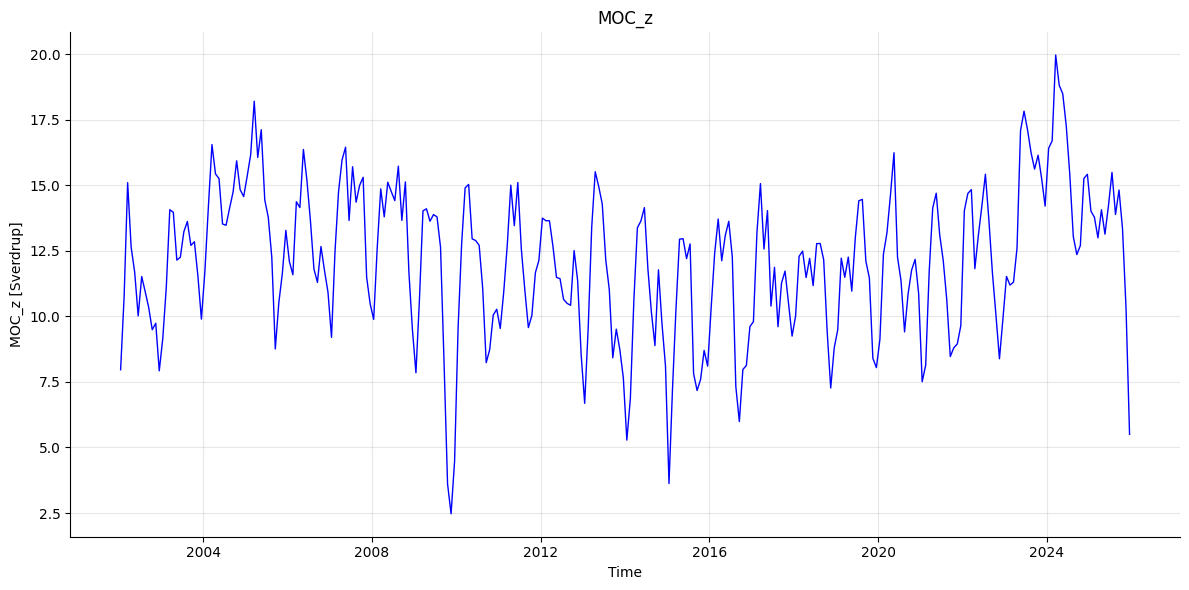

In [4]:
plotting.plot_time_series(ds,"MOC")

In [5]:
ds

<xarray.Dataset> Size: 12kB
Dimensions:      (TIME: 288)
Coordinates:
  * TIME         (TIME) datetime64[ns] 2kB 2002-01-16T05:17:31.200000 ... 202...
Data variables:
    TRANS_EKMAN  (TIME) float64 2kB -6.496 -6.588 -3.661 ... -4.636 -6.764
    TRANS_GEO    (TIME) float64 2kB 14.46 17.34 18.77 16.24 ... 16.4 14.94 12.27
    MOC          (TIME) float64 2kB 7.968 10.76 15.11 12.64 ... 13.34 10.3 5.502
    MHT          (TIME) float64 2kB 0.1834 0.3508 0.5646 ... 0.2112 0.007742
Attributes: (12/33)
    summary:                               41N transport estimates dataset
    description:                           41N transport estimates dataset
    program:                               41N
    project:                               Atlantic Meridional Overturning Ci...
    license:                               CC-BY-4.0
    citation:                              Willis, J. K., and Hobbs, W. R., A...
    ...                                    ...
    processing_datasource:                 wh41n
    variable_mapping:                      {'Ekman (Sv)': 'TRANS_EKMAN', 'Geo...
    original_variable_metadata:            {'Ekman (Sv)': {'long_name': 'Ekma...
    applied_variable_mapping:              {'Ekman (Sv)': 'TRANS_EKMAN', 'Geo...
    files:                                 {'hobbs_willis_amoc41N_tseries.txt...
    version:                               v5

In [6]:
analysis.summary_stats(MOC)

{'n': 288,
 'n_missing': np.int64(0),
 'mean': np.float64(12.135603915625),
 'std': np.float64(2.811908456102489),
 'median': np.float64(12.271187),
 'min': np.float64(2.4702439),
 'max': np.float64(19.97875),
 'range': np.float64(17.5085061)}

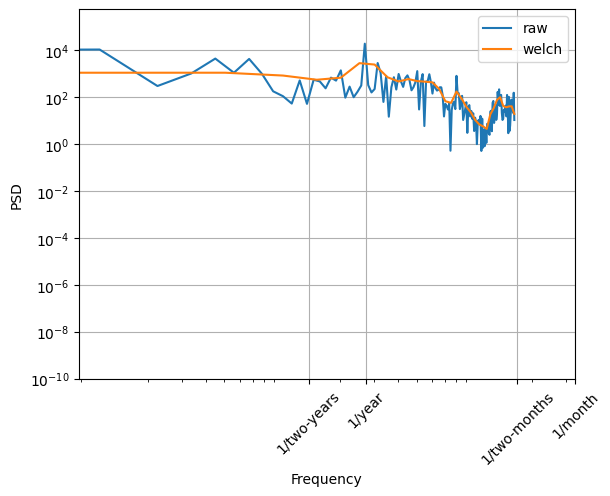

In [37]:
f,psd=spectra.raw_periodogram(MOC,31)
fw,psdw=spectra.welch_psd(MOC,31,64)

periods = {
        "1/day":    1 / 1,
        "1/week":   1 / 7,
        "1/month":  1 / 30,
        "1/year":   1 / 365,
    }


plt.loglog(f,psd,label="raw")
plt.loglog(fw,psdw,label="welch")
plt.xticks([1/730, 1/365, 1/60, 1/30],["1/two-years","1/year", "1/two-months", "1/month",],rotation=45)
plt.grid(True)
plt.xlabel("Frequency")
plt.ylabel("PSD")
plt.ylim(10e-11)
plt.legend()
plt.savefig("Lattekamp_spectrum.png")
plt.show()

In [10]:
rapid=data.load_sample_dataset()

Summary for array 'rapid':
Total datasets loaded: 1

Dataset 1:
  Source file: moc_transports.nc
  Time coverage: 2004-04-02 to 2023-02-11
  Dimensions:
    - TIME: 13779
  Variables:
    - t_therm10: shape (13779,)
    - t_aiw10: shape (13779,)
    - t_ud10: shape (13779,)
    - t_ld10: shape (13779,)
    - t_bw10: shape (13779,)
    - t_gs10: shape (13779,)
    - t_ek10: shape (13779,)
    - t_umo10: shape (13779,)
    - moc_mar_hc10: shape (13779,)



In [11]:
rapid.t_umo10

<xarray.DataArray 't_umo10' (TIME: 13779)> Size: 110kB
[13779 values with dtype=float64]
Coordinates:
  * TIME     (TIME) datetime64[ns] 110kB 2004-04-02 ... 2023-02-11
Attributes:
    long_name:   upper Mid-Ocean transport
    units:      Sv

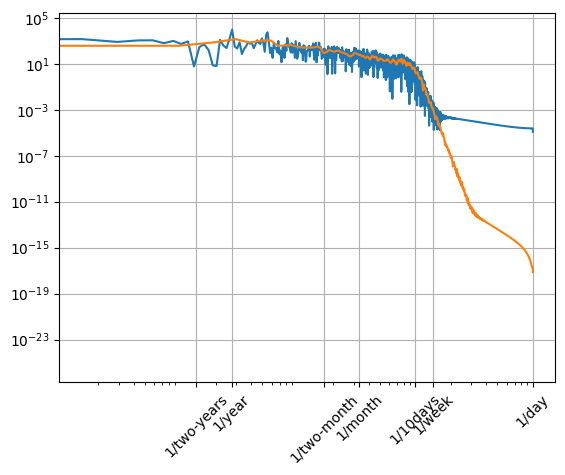

In [30]:
rapid_MOC=rapid["t_umo10"]
rapid_MOC=rapid_MOC[~np.isnan(rapid_MOC)]
f,psd=spectra.raw_periodogram(rapid_MOC,0.5)
fw,psdw=spectra.welch_psd(rapid_MOC,0.5,2048)


periods = {
        "1/day":    1 / 1,
        "1/week":   1 / 7,
        "1/month":  1 / 30,
        "1/year":   1 / 365,
    }


plt.loglog(f,psd)
plt.loglog(fw,psdw)
plt.xticks([1/730, 1/365, 1/60, 1/30,1/10, 1/7, 1/1],
           ["1/two-years","1/year", "1/two-month", "1/month","1/10days", "1/week", "1/day"],rotation=45)
plt.grid(True)